# STEP 1: Import tools

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# STEP 2: Load Data


In [12]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_table(url, header=None, names=['label', 'message'])

In [16]:
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


# STEP 3: Exploratory Data Analysis (EDA)

In [18]:
print("--- EDA: Data Overview ---")
print(df.head())

print(df.info()) # Shows data types and null values

--- EDA: Data Overview ---
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


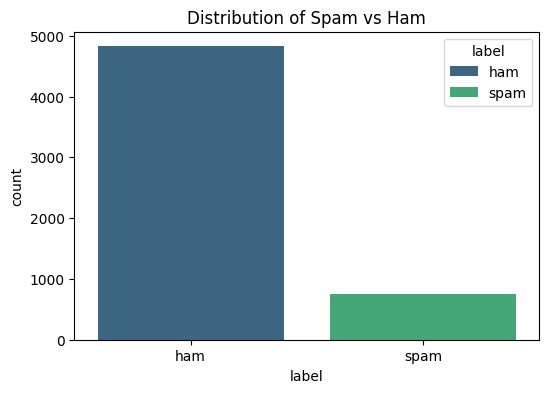

In [21]:
# Check for Class Imbalance (How many spam vs ham)
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=True)
plt.title('Distribution of Spam vs Ham')
plt.show()

# STEP 4: PREPROCESSING & TRAINING

In [28]:
# Convert 'ham' and 'spam' into numbers (0 and 1)
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

X = df['message']
y = df['label']

df

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [24]:
# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Use TF-IDF Vectorizer to turn text into numbers
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [26]:
# Train Multinomial Naive Bayes Model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

# STEP 5: VISUALIZATION OF RESULTS

In [27]:

y_pred = model.predict(X_test_tfidf)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 96.68%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.75      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



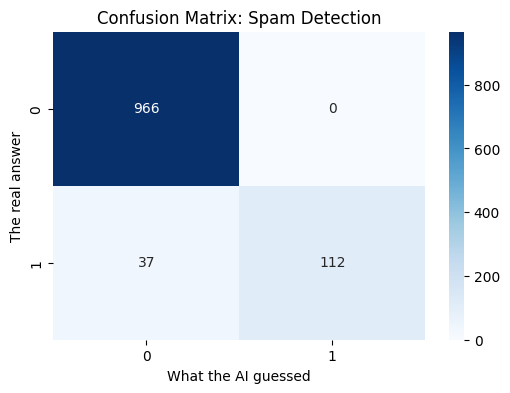

In [34]:
# Display a Confusion Matrix to show where the model made errors
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("What the AI guessed")
plt.ylabel("The real answer")
plt.title("Confusion Matrix: Spam Detection")
plt.show()

# STEP 6: PREDICTION

In [29]:
# Function to predict whether a new message is spam
def predict_message(new_msg):
    new_msg_tfidf = tfidf_vectorizer.transform([new_msg])
    prediction = model.predict(new_msg_tfidf)
    return "Spam" if prediction[0] == 1 else "Ham"

In [30]:
# Test example
sample = "Congratulations! You've won a $1,000 Walmart Gift Card. Click here to claim."
print(f"\nSample Message: {sample}")
print(f"Result: {predict_message(sample)}")


Sample Message: Congratulations! You've won a $1,000 Walmart Gift Card. Click here to claim.
Result: Spam
